# Adult dataset - cu CategoricalNB

# Exemplu clasificare Bayesiana

Se considera colectia de date:
https://archive.ics.uci.edu/ml/datasets/Adult
Vrem sa aplicam algoritmul de clasificare pentru a estima daca venitul unei persoane este <50K sau > 50K 

In [0]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [0]:

df = pd.read_csv('adult.data', header = None, sep = ', ', engine='python')

names_adult_dataset = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df.columns = names_adult_dataset

In [0]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [0]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [0]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [0]:
df.describe(include = 'object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [0]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [0]:
df.tail(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [0]:
display(df.tail(10))

age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [0]:
df.isnull().sum() 

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [0]:
df['workclass'].dtype
df['hours-per-week'].dtype  

dtype('int64')

In [0]:
df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

In [0]:
for col in df.columns:
    if df[col].dtype == 'object':
        display(df[col].unique())

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

array(['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
       'Other-relative'], dtype=object)

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

array(['Male', 'Female'], dtype=object)

array(['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

array(['<=50K', '>50K'], dtype=object)

In [0]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [0]:
df = df.dropna(how = 'any')

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [0]:
df.replace(to_replace = '?', value = np.nan, inplace = True)

In [0]:
df['workclass'].isnull().sum()  

1836

In [0]:
df.reset_index(drop=True, inplace=True)


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.5+ MB


In [0]:
df.isnull().sum()   

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [0]:
df.dropna(how = 'any', inplace = True)
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [0]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [0]:
X = df.drop(columns = {'income'})
y = df['income']

In [0]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
30158,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
30159,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
30160,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [0]:
y

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
30157    <=50K
30158     >50K
30159    <=50K
30160    <=50K
30161     >50K
Name: income, Length: 30162, dtype: object

In [0]:
# Selectam atributele de tip discret, mai putin atributul income
num_atr_discrete = [col for col in df.columns if df[col].dtype == 'object' and col!='income'] 
num_atr_discrete

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [0]:
# Selectam atributele de tip continuu
num_atr_continui = [col for col in df.columns if df[col].dtype != 'object']
print(num_atr_continui)


['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [0]:
X_copy = X.copy()
X_copy

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
30158,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
30159,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
30160,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [0]:
# Discretizam atributele continui
from sklearn.preprocessing import KBinsDiscretizer

n = 3 # numar de intervale
disctr = KBinsDiscretizer(n_bins = 3, encode='ordinal', strategy='uniform') # equal-width
disctr.fit(X[num_atr_continui])
X_copy[num_atr_continui] = disctr.transform(X[num_atr_continui])
X_copy

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.0,State-gov,0.0,Bachelors,2.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,1.0,United-States
1,1.0,Self-emp-not-inc,0.0,Bachelors,2.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,0.0,United-States
2,0.0,Private,0.0,HS-grad,1.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,1.0,United-States
3,1.0,Private,0.0,11th,1.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,1.0,United-States
4,0.0,Private,0.0,Bachelors,2.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,1.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,0.0,Private,0.0,Assoc-acdm,2.0,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,1.0,United-States
30158,0.0,Private,0.0,HS-grad,1.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,1.0,United-States
30159,1.0,Private,0.0,HS-grad,1.0,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,1.0,United-States
30160,0.0,Private,0.0,HS-grad,1.0,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,0.0,United-States


In [0]:
X_copy['age']
X_copy['age'].unique()
X_copy['hours-per-week'].unique()
X_copy['education-num'].value_counts()

1.0    18763
2.0     9903
0.0     1496
Name: education-num, dtype: int64

In [0]:
# Transformam atributele discrete in valori numerice
# folosind OrdinalEncoder

from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
enc.fit(X[num_atr_discrete])
X_copy[num_atr_discrete] = enc.transform(X[num_atr_discrete])
X_copy

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.0,5.0,0.0,9.0,2.0,4.0,0.0,1.0,4.0,1.0,0.0,0.0,1.0,38.0
1,1.0,4.0,0.0,9.0,2.0,2.0,3.0,0.0,4.0,1.0,0.0,0.0,0.0,38.0
2,0.0,2.0,0.0,11.0,1.0,0.0,5.0,1.0,4.0,1.0,0.0,0.0,1.0,38.0
3,1.0,2.0,0.0,1.0,1.0,2.0,5.0,0.0,2.0,1.0,0.0,0.0,1.0,38.0
4,0.0,2.0,0.0,9.0,2.0,2.0,9.0,5.0,2.0,0.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,0.0,2.0,0.0,7.0,2.0,2.0,12.0,5.0,4.0,0.0,0.0,0.0,1.0,38.0
30158,0.0,2.0,0.0,11.0,1.0,2.0,6.0,0.0,4.0,1.0,0.0,0.0,1.0,38.0
30159,1.0,2.0,0.0,11.0,1.0,6.0,0.0,4.0,4.0,0.0,0.0,0.0,1.0,38.0
30160,0.0,2.0,0.0,11.0,1.0,4.0,0.0,3.0,4.0,1.0,0.0,0.0,0.0,38.0


In [0]:
X_copy['workclass'].unique()
#df['workclass'].unique()
X_copy['workclass'].value_counts()

2.0    22286
4.0     2499
1.0     2067
5.0     1279
3.0     1074
0.0      943
6.0       14
Name: workclass, dtype: int64

In [0]:
X_copy

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.0,5.0,0.0,9.0,2.0,4.0,0.0,1.0,4.0,1.0,0.0,0.0,1.0,38.0
1,1.0,4.0,0.0,9.0,2.0,2.0,3.0,0.0,4.0,1.0,0.0,0.0,0.0,38.0
2,0.0,2.0,0.0,11.0,1.0,0.0,5.0,1.0,4.0,1.0,0.0,0.0,1.0,38.0
3,1.0,2.0,0.0,1.0,1.0,2.0,5.0,0.0,2.0,1.0,0.0,0.0,1.0,38.0
4,0.0,2.0,0.0,9.0,2.0,2.0,9.0,5.0,2.0,0.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,0.0,2.0,0.0,7.0,2.0,2.0,12.0,5.0,4.0,0.0,0.0,0.0,1.0,38.0
30158,0.0,2.0,0.0,11.0,1.0,2.0,6.0,0.0,4.0,1.0,0.0,0.0,1.0,38.0
30159,1.0,2.0,0.0,11.0,1.0,6.0,0.0,4.0,4.0,0.0,0.0,0.0,1.0,38.0
30160,0.0,2.0,0.0,11.0,1.0,4.0,0.0,3.0,4.0,1.0,0.0,0.0,0.0,38.0


In [0]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import CategoricalNB
 
# X_train, X_test, y_train, y_test = train_test_split(X_copy, y, test_size=0.2, random_state=0, stratify = y)

X_train, X_test, y_train, y_test = train_test_split(X_copy, y, test_size=0.2, random_state=0)

 

In [0]:
model = CategoricalNB()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_test)
print(y_pred)

1963     <=50K
14485    <=50K
26933    <=50K
25507    <=50K
8573     <=50K
         ...  
4528      >50K
4610      >50K
17304    <=50K
9349      >50K
23762    <=50K
Name: income, Length: 6033, dtype: object
['<=50K' '<=50K' '<=50K' ... '<=50K' '<=50K' '<=50K']


In [0]:
print(y_test)

1963     <=50K
14485    <=50K
26933    <=50K
25507    <=50K
8573     <=50K
         ...  
4528      >50K
4610      >50K
17304    <=50K
9349      >50K
23762    <=50K
Name: income, Length: 6033, dtype: object


In [0]:
print(y_pred)

['<=50K' '<=50K' '<=50K' ... '<=50K' '<=50K' '<=50K']


In [0]:
(y_pred != y_test).sum() #1132 de valori gresite (estimari gresite pe mt de testare)

1132

In [0]:
y_test.count()

6033

In [0]:
error = (y_pred != y_test).sum()/y_test.size
error

0.18763467594894745

In [0]:
(y_pred!=y_test).sum()

1132

In [0]:
error = (y_pred != y_test).sum()/y_test.size
error



0.18900660218025486

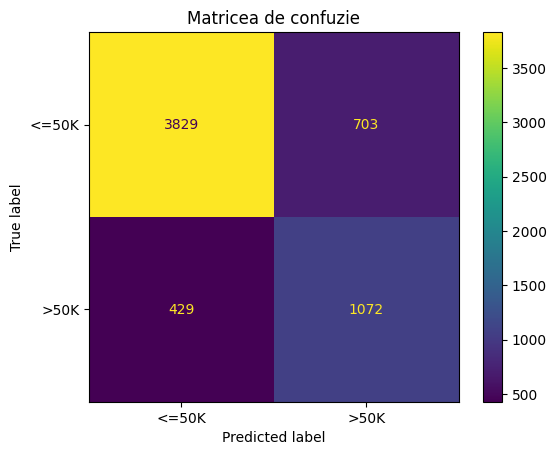

array([[3829,  703],
       [ 429, 1072]])

In [0]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matricea de confuzie")
plt.show()
confusion_matrix(y_test, y_pred)

In [0]:
confusion_matrix(y_test, y_pred)

array([[3829,  703],
       [ 429, 1072]])

Matricea de Confuzie creată are patru cadrane diferite:

TN True Negative (Cadranul Stânga-Sus)
FP False Pozitive (Cadranul Dreapta-Sus)
FN False Negative (Cadranul Stânga-Jos)
TP True Positive  (Cadranul Dreapta-Jos)

True înseamnă că valorile au fost prezise corect, False înseamnă că a existat o eroare sau o predicție greșită.

Acum că am realizat o Matrice de Confuzie, putem calcula diferite măsuri pentru a cuantifica calitatea modelului. Mai întâi, să ne uităm la Acuratețe.

In [0]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
# Sensitivity, hit rate, recall, or true positive rate
Sensitivity = float(TP)/(TP+FN)*100
# Specificity or true negative rate
Specificity = float(TN)/(TN+FP)*100
# Precision or positive predictive value
Precision = float(TP)/(TP+FP)*100
# Negative predictive value
NPV = float(TN)/(TN+FN)*100
# Fall out or false positive rate
FPR = float(FP)/(FP+TN)*100
# False negative rate
FNR = float(FN)/(TP+FN)*100
# False discovery rate
FDR = float(FP)/(TP+FP)*100
# Overall accuracy
ACC = float(TP+TN)/(TP+FP+FN+TN)*100

display(f"TN= {TN}")
display(f"FP= {FP}")
display(f"FN= {FN}")
display(f"TP= {TP}")
display(f"Sensitivity or TPR: {Sensitivity}%")
display(f"Specificity or TNR: {Specificity}%")
display(f"Precision: {Precision}%")
display(f"Negative Predictive Value: {NPV}%")
display(f"False Positive Rate: {FPR}%")
display(f"False Negative Rate: {FNR}%")
display(f"False Discovery Rate: {FDR}%")
display(f"Accuracy: {ACC}%")

'TN= 3829'

'FP= 703'

'FN= 429'

'TP= 1072'

'Sensitivity or TPR: 71.41905396402399%'

...

'Negative Predictive Value: 89.92484734617192%'

'False Positive Rate: 15.511915269196821%'

'False Negative Rate: 28.58094603597602%'

'False Discovery Rate: 39.605633802816904%'

'Accuracy: 81.23653240510525%'

In [0]:
df1 = df.head(10)
df1

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [0]:
# Generare baza de date pentru exemplul de Clasificare Bayesiana din wb DM&ML - 14.05.2023

df2 = df1[['workclass','relationship', 'income']]
df2

,workclass,relationship,income
0,State-gov,Not-in-family,<=50K
1,Self-emp-not-inc,Husband,<=50K
2,Private,Not-in-family,<=50K
3,Private,Husband,<=50K
4,Private,Wife,<=50K
5,Private,Wife,<=50K
6,Private,Not-in-family,<=50K
7,Self-emp-not-inc,Husband,>50K
8,Private,Not-in-family,>50K
9,Private,Husband,>50K


In [0]:
df2.groupby(['workclass', 'income'])['income'].count()

workclass         income
Private           <=50K     5
                  >50K      2
Self-emp-not-inc  <=50K     1
                  >50K      1
State-gov         <=50K     1
Name: income, dtype: int64

In [0]:
 df2.groupby(['relationship', 'income'])['income'].count()

relationship   income
Husband        <=50K     2
               >50K      2
Not-in-family  <=50K     3
               >50K      1
Wife           <=50K     2
Name: income, dtype: int64

In [0]:
df2 = df.tail(20)
df2

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32538,38,Private,139180,Bachelors,13,Divorced,Prof-specialty,Unmarried,Black,Female,15020,0,45,United-States,>50K
32540,45,State-gov,252208,HS-grad,9,Separated,Adm-clerical,Own-child,White,Female,0,0,40,United-States,<=50K
32543,45,Local-gov,119199,Assoc-acdm,12,Divorced,Prof-specialty,Unmarried,White,Female,0,0,48,United-States,<=50K
32544,31,Private,199655,Masters,14,Divorced,Other-service,Not-in-family,Other,Female,0,0,30,United-States,<=50K
32545,39,Local-gov,111499,Assoc-acdm,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K
32546,37,Private,198216,Assoc-acdm,12,Divorced,Tech-support,Not-in-family,White,Female,0,0,40,United-States,<=50K
32547,43,Private,260761,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Mexico,<=50K
32548,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K
32549,43,State-gov,255835,Some-college,10,Divorced,Adm-clerical,Other-relative,White,Female,0,0,40,United-States,<=50K
32550,43,Self-emp-not-inc,27242,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K


In [0]:
df2 = df2[['workclass','relationship', 'income']]
df2

,workclass,relationship,income
32538,Private,Unmarried,>50K
32540,State-gov,Own-child,<=50K
32543,Local-gov,Unmarried,<=50K
32544,Private,Not-in-family,<=50K
32545,Local-gov,Wife,>50K
32546,Private,Not-in-family,<=50K
32547,Private,Husband,<=50K
32548,Self-emp-not-inc,Not-in-family,<=50K
32549,State-gov,Other-relative,<=50K
32550,Self-emp-not-inc,Husband,<=50K


In [0]:
df2.groupby(['workclass', 'income'])['income'].count()

workclass         income
Local-gov         <=50K      1
                  >50K       1
Private           <=50K     10
                  >50K       3
Self-emp-inc      >50K       1
Self-emp-not-inc  <=50K      2
State-gov         <=50K      2
Name: income, dtype: int64

In [0]:
df2.groupby(['relationship', 'income'])['income'].count()

relationship    income
Husband         <=50K     4
                >50K      2
Not-in-family   <=50K     5
Other-relative  <=50K     1
Own-child       <=50K     2
Unmarried       <=50K     2
                >50K      1
Wife            <=50K     1
                >50K      2
Name: income, dtype: int64